# Multi-Class Waste Image Classification Using Transfer Learning with EfficientNetB0 and MobileNetV2 on a Multi-Source Dataset

Notebook revisi untuk eksperimen **multi-class image classification** dengan dua backbone transfer learning: **MobileNetV2** dan **EfficientNetB0**.

> **Catatan metodologis:** judul penelitian menggunakan istilah *multi-class* karena setiap gambar memiliki tepat satu kelas dan classifier menggunakan **softmax**. Nama repositori GitHub masih mengandung istilah *Multi-Label*, tetapi implementasi notebook ini tetap diperlakukan sebagai **multi-class single-label classification**.


## 1. Research Scope & Target Classes

Target Class dipertahankan menjadi enam kelas utama yang konsisten dengan skema klasifikasi:

- `cardboard`
- `glass`
- `metal`
- `paper`
- `plastic`
- `trash`


In [ ]:
# 0. Environment, Reproducibility, and Configuration
import os
import re
import gc
import sys
import math
import json
import shutil
import hashlib
import zipfile
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import tensorflow as tf
from IPython.display import display

ImageFile.LOAD_TRUNCATED_IMAGES = False

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# Dataset repository
GITHUB_REPO_URL = (
    "https://github.com/N4th0wl/"
    "Multi-Label-Waste-Image-Classification-With-EfficientNetB0-MobileNetV2-on-Multi-Source-Dataset.git"
)
REPO_DIR = Path("/content/waste_classification_repo")

# Working directories
RAW_EXTRACT_DIR = Path("/content/raw_dataset_extracts")
COMBINED_DIR = Path("/content/dataset_combined")
DATASET_DIR = Path("/content/dataset")

TARGET_CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

IMG_SIZE = (288, 288)
INPUT_SHAPE = (288, 288, 3)
BATCH_SIZE = 32

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

EPOCHS_BASELINE = 12
EPOCHS_FINE_TUNE = 30

# Jumlah layer teratas backbone yang dibuka saat fine-tuning (BatchNorm tetap frozen).
FINE_TUNE_LAST_N = {
    "mobilenet_v2": 60,      # +-40% layer teratas dari 154 layer
    "efficientnet_b0": 90,   # +-40% layer teratas dari 238 layer
}

BASE_LR = 1e-3
FINE_TUNE_LR = 1e-4          # sebelumnya 1e-5: terlalu kecil sehingga backbone nyaris tidak belajar
DROPOUT_RATE = 0.50
LABEL_SMOOTHING = 0.10

PRETRAINED_WEIGHTS = "imagenet"

AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    print(
        "\n[PERINGATAN] GPU tidak terdeteksi. Training akan berjalan di CPU "
        "(+-6-10 menit/epoch pada run sebelumnya).\n"
        "Di Colab: Runtime > Change runtime type > T4 GPU, lalu jalankan ulang dari awal."
    )

TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Import Dataset Directly from GitHub

Versi sebelumnya masih mengunduh `TrashNet` dari repository lain dan mengharapkan `/content/additional_datasets` sudah tersedia. Itu membuat eksperimen tidak benar-benar reproducible dari repositori penelitian.

Versi ini menjadikan **repository GitHub penelitian** sebagai sumber utama. Notebook akan:

1. clone repository dengan shallow clone;
2. mencoba menarik Git LFS bila tersedia;
3. mengekstrak arsip dataset yang relevan bila arsip disimpan di repository;
4. mencari folder gambar berlabel secara otomatis;
5. mempertahankan informasi `source` setiap gambar untuk analisis multi-source.

Apabila repository tidak menyimpan file gambar/arsip dataset, notebook akan berhenti dengan pesan yang jelas. Notebook tidak akan diam-diam mengganti dataset penelitian dengan sumber lain.


In [ ]:
# 1. Clone Research Repository and Recover Dataset Assets
for path in [REPO_DIR, RAW_EXTRACT_DIR, COMBINED_DIR, DATASET_DIR]:
    if path.exists():
        shutil.rmtree(path)

REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
RAW_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print("=== Cloning research repository from GitHub ===")
clone_result = subprocess.run(
    ["git", "clone", "--depth", "1", GITHUB_REPO_URL, str(REPO_DIR)],
    capture_output=True,
    text=True,
)

if clone_result.returncode != 0:
    raise RuntimeError(
        "GitHub clone gagal. Pastikan repository dapat diakses publik dari Colab.\n"
        + clone_result.stderr
    )

# Git LFS support, bila tersedia
lfs_check = subprocess.run(
    ["git", "lfs", "version"],
    capture_output=True,
    text=True,
)

if lfs_check.returncode == 0:
    lfs_pull = subprocess.run(
        ["git", "lfs", "pull"],
        cwd=REPO_DIR,
        capture_output=True,
        text=True,
    )
    if lfs_pull.returncode == 0:
        print("Git LFS assets berhasil ditarik.")
    else:
        print("Git LFS tersedia, tetapi tidak ada LFS asset yang berhasil ditarik.")
else:
    print("Git LFS tidak tersedia; melanjutkan dengan file yang terdapat pada clone.")

# Ekstrak arsip dataset yang terlihat relevan.
ARCHIVE_KEYWORDS = ("dataset", "trash", "waste", "garbage", "data")

archive_files = [
    p for p in REPO_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() == ".zip"
    and any(k in p.name.lower() for k in ARCHIVE_KEYWORDS)
    and ".git" not in p.parts
]

for archive in archive_files:
    target = RAW_EXTRACT_DIR / archive.stem
    target.mkdir(parents=True, exist_ok=True)
    try:
        with zipfile.ZipFile(archive, "r") as zf:
            zf.extractall(target)
        print(f"Extracted: {archive.name} -> {target}")
    except zipfile.BadZipFile:
        print(f"Skipping invalid ZIP: {archive}")

print("Repository:", REPO_DIR)
print("Relevant ZIP files:", len(archive_files))


=== Cloning research repository from GitHub ===
Git LFS tidak tersedia; melanjutkan dengan file yang terdapat pada clone.
Repository: /content/waste_classification_repo
Relevant ZIP files: 0


In [ ]:
# 2. Discover Multi-Source Labeled Images
# Only semantically compatible labels are accepted by default.
# Ambiguous source labels such as "recyclable" are excluded rather
# than arbitrarily mapped to "plastic".
CLASS_ALIASES = {
    "cardboard": "cardboard",
    "glass": "glass",
    "metal": "metal",
    "paper": "paper",
    "plastic": "plastic",
    "trash": "trash",
    "organic": None,
    "vegetation": None,
    "miscellaneous": None,
    "food waste": None,
    "textile": None,
    "non-recyclable": None,
    "recyclable": None,
}

def normalize_folder_name(name):
    name = str(name).strip().lower()
    name = name.replace("_", " ").replace("-", " ")
    name = re.sub(r"\s+", " ", name)
    return name

GENERIC_CONTAINER_DIRS = {
    "data", "dataset", "datasets", "additional datasets", "additional_datasets",
    "raw", "processed", "images", "image", "train", "training",
    "val", "valid", "validation", "test", "testing"
}

def canonicalize_class_folder(name):
    normalized = normalize_folder_name(name)
    # Supports folder names such as "0_cardboard", "01-cardboard".
    normalized = re.sub(r"^\d+[\s._-]*", "", normalized)

    if normalized in CLASS_ALIASES:
        return CLASS_ALIASES[normalized], normalized

    for alias in sorted(CLASS_ALIASES.keys(), key=len, reverse=True):
        if normalized.endswith(" " + alias):
            return CLASS_ALIASES[alias], alias

    return None, None

def infer_class_from_path(filepath, root_dir):
    relative_parts = list(filepath.relative_to(root_dir).parts[:-1])
    for part in reversed(relative_parts):
        label, canonical_name = canonicalize_class_folder(part)
        if label in TARGET_CLASSES:
            return label, canonical_name
    return None, None

def infer_source_from_path(filepath, root_dir, original_class_folder):
    rel_parts = list(filepath.relative_to(root_dir).parts[:-1])

    # data/source_a/train/cardboard/image.jpg -> source_a
    candidates = [
        normalize_folder_name(p)
        for p in rel_parts
        if normalize_folder_name(p) not in GENERIC_CONTAINER_DIRS
        and normalize_folder_name(p) != normalize_folder_name(original_class_folder)
    ]

    if not candidates:
        return "github_repo"

    return candidates[0].replace(" ", "_")

SEARCH_ROOTS = [REPO_DIR, RAW_EXTRACT_DIR]
records = []
seen_paths = set()

for search_root in SEARCH_ROOTS:
    if not search_root.exists():
        continue

    for filepath in search_root.rglob("*"):
        if not filepath.is_file():
            continue
        if filepath.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        if ".git" in filepath.parts:
            continue

        absolute = str(filepath.resolve())
        if absolute in seen_paths:
            continue

        label, original_class = infer_class_from_path(filepath, search_root)
        if label not in TARGET_CLASSES:
            continue

        source = infer_source_from_path(filepath, search_root, original_class)

        records.append({
            "path": filepath,
            "label": label,
            "original_class": original_class,
            "source": source,
        })
        seen_paths.add(absolute)

images_df = pd.DataFrame(records)

if images_df.empty:
    raise FileNotFoundError(
        "Tidak ditemukan dataset gambar berlabel enam kelas di repository GitHub. "
        "Pastikan image files atau ZIP dataset benar-benar disimpan di repository "
        "(atau melalui Git LFS), lalu jalankan ulang notebook."
    )

print("Jumlah gambar yang ditemukan:", len(images_df))
print("Distribusi label:")
display(images_df["label"].value_counts().reindex(TARGET_CLASSES, fill_value=0).to_frame("count"))

print("\nDistribusi source:")
display(images_df["source"].value_counts().to_frame("count"))

print("\nContoh path yang terdeteksi:")
display(images_df.head(10))


Jumlah gambar yang ditemukan: 7042
Distribusi label:


,count
label,
cardboard,858
glass,857
metal,1037
paper,853
plastic,1842
trash,1595



Distribusi source:


,count
source,
github_repo,7042



Contoh path yang terdeteksi:


,path,label,original_class,source
0,/content/waste_classification_repo/dataset/gla...,glass,glass,github_repo
1,/content/waste_classification_repo/dataset/gla...,glass,glass,github_repo
2,/content/waste_classification_repo/dataset/gla...,glass,glass,github_repo
3,/content/waste_classification_repo/dataset/gla...,glass,glass,github_repo
4,/content/waste_classification_repo/dataset/gla...,glass,glass,github_repo
5,/content/waste_classification_repo/dataset/gla...,glass,glass,github_repo
6,/content/waste_classification_repo/dataset/gla...,glass,glass,github_repo
7,/content/waste_classification_repo/dataset/gla...,glass,glass,github_repo
8,/content/waste_classification_repo/dataset/gla...,glass,glass,github_repo
9,/content/waste_classification_repo/dataset/gla...,glass,glass,github_repo


## 3. Dataset Validation, Corruption Check, and Duplicate Removal


In [ ]:
# 3. Validate Images + Remove Exact / Perceptual Duplicates

def sha256_file(filepath, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def phash64(filepath):
    # Compact perceptual hash using low-frequency DCT coefficients.
    with Image.open(filepath) as img:
        img = img.convert("L").resize((32, 32))
        arr = np.asarray(img, dtype=np.float32)
    dct = cv2.dct(arr)
    low_freq = dct[:8, :8]
    threshold = np.median(low_freq[1:, 1:])
    bits = low_freq > threshold

    value = 0
    for bit in bits.flatten():
        value = (value << 1) | int(bit)
    return f"{value:016x}"

valid_records = []
corrupt_count = 0

print("=== Validating image integrity ===")
for row in images_df.itertuples(index=False):
    try:
        with Image.open(row.path) as img:
            img.verify()

        # Re-open after verify to make sure decoding is possible.
        with Image.open(row.path) as img:
            img.convert("RGB").resize((32, 32))
    except Exception:
        corrupt_count += 1
        continue

    valid_records.append({
        "path": str(row.path),
        "label": row.label,
        "original_class": row.original_class,
        "source": row.source,
        "sha256": sha256_file(row.path),
        "phash": phash64(row.path),
    })

clean_df = pd.DataFrame(valid_records)

# Remove byte-identical files first.
before_exact = len(clean_df)
clean_df = clean_df.drop_duplicates(subset=["sha256"], keep="first").reset_index(drop=True)
exact_duplicates = before_exact - len(clean_df)

# Remove exact perceptual-hash duplicates within the same semantic class.
# This is deliberately conservative: we do not use a Hamming-distance
# threshold because similar-looking but genuinely different waste images
# should not be removed merely for visual similarity.
before_phash = len(clean_df)
clean_df = clean_df.drop_duplicates(subset=["label", "phash"], keep="first").reset_index(drop=True)
phash_duplicates = before_phash - len(clean_df)

print(f"Gambar rusak              : {corrupt_count}")
print(f"Duplikat SHA-256          : {exact_duplicates}")
print(f"Duplikat exact pHash      : {phash_duplicates}")
print(f"Total gambar setelah clean: {len(clean_df)}")

print("\nDistribusi kelas setelah cleaning:")
display(clean_df["label"].value_counts().reindex(TARGET_CLASSES, fill_value=0).to_frame("count"))

missing_classes = [c for c in TARGET_CLASSES if c not in set(clean_df["label"])]
if missing_classes:
    raise ValueError(f"Kelas target tidak memiliki data setelah cleaning: {missing_classes}")


=== Validating image integrity ===
Gambar rusak              : 0
Duplikat SHA-256          : 48
Duplikat exact pHash      : 92
Total gambar setelah clean: 6902

Distribusi kelas setelah cleaning:


,count
label,
cardboard,858
glass,836
metal,980
paper,823
plastic,1830
trash,1575


Train: 4830 (69.98%)
Val  : 1036 (15.01%)
Test : 1036 (15.01%)


split,test,train,val
label,,,
cardboard,129,600,129
glass,125,585,126
metal,147,686,147
paper,124,576,123
plastic,275,1280,275
trash,236,1103,236


<Figure size 1200x600 with 0 Axes>

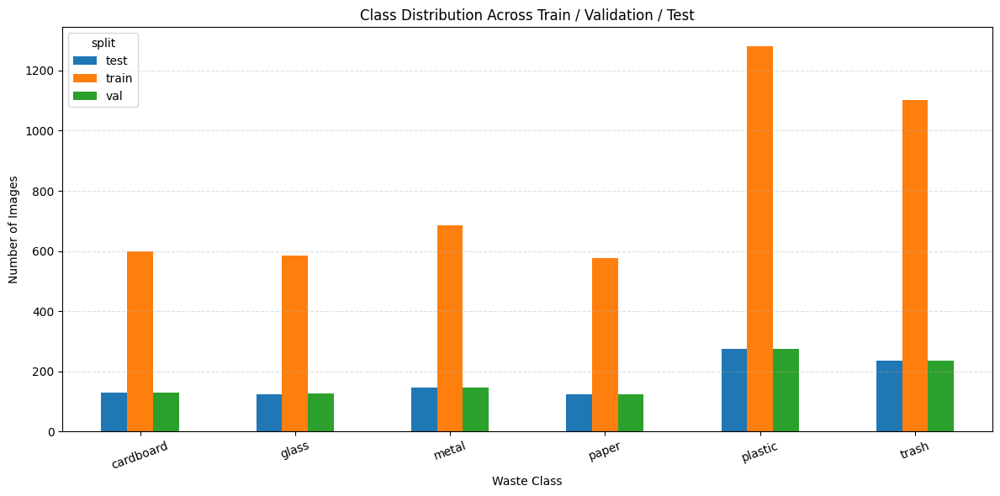

Distribusi multi-source:


split,test,train,val
source,,,
github_repo,1036,4830,1036


In [ ]:
# 4. Stratified 70/15/15 Split BEFORE Augmentation

# First split: 85% train+val, 15% test
train_val_df, test_df = train_test_split(
    clean_df,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=clean_df["label"],
)
train_val_df = train_val_df.copy()
test_df = test_df.copy()

# Second split: 15% validation overall = 15/85 of the train+val partition
val_fraction_of_train_val = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_fraction_of_train_val,
    random_state=SEED,
    stratify=train_val_df["label"],
)
train_df = train_df.copy()
val_df = val_df.copy()

for frame, split_name in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    frame["split"] = split_name

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
split_manifest = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"Train: {len(train_df)} ({len(train_df)/len(split_manifest):.2%})")
print(f"Val  : {len(val_df)} ({len(val_df)/len(split_manifest):.2%})")
print(f"Test : {len(test_df)} ({len(test_df)/len(split_manifest):.2%})")

dist_table = (
    split_manifest.groupby(["label", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(TARGET_CLASSES)
)

display(dist_table)

plt.figure(figsize=(12, 6))
dist_table.plot(kind="bar", figsize=(12, 6))
plt.title("Class Distribution Across Train / Validation / Test")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

source_split_table = (
    split_manifest.groupby(["source", "split"])
    .size()
    .unstack(fill_value=0)
)

print("Distribusi multi-source:")
display(source_split_table)


In [ ]:
# 5. Materialize Clean Splits as Directory Dataset

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

for split_name in ["train", "val", "test"]:
    for class_name in TARGET_CLASSES:
        (DATASET_DIR / split_name / class_name).mkdir(parents=True, exist_ok=True)

def safe_filename(source, original_path, row_idx):
    original = Path(original_path)
    stem = re.sub(r"[^A-Za-z0-9._-]+", "_", original.stem)
    ext = original.suffix.lower()
    source = re.sub(r"[^A-Za-z0-9._-]+", "_", source)
    return f"{source}_{row_idx:06d}_{stem}{ext}"

materialized_rows = []

for frame in [train_df, val_df, test_df]:
    split_name = frame["split"].iloc[0]

    for idx, row in frame.iterrows():
        filename = safe_filename(row["source"], row["path"], idx)
        dest = DATASET_DIR / split_name / row["label"] / filename
        shutil.copy2(row["path"], dest)

        materialized_rows.append({
            "path": str(dest),
            "label": row["label"],
            "source": row["source"],
            "split": split_name,
            "original_path": row["path"],
        })

materialized_df = pd.DataFrame(materialized_rows)

print("Materialized dataset:", DATASET_DIR)
for split_name in ["train", "val", "test"]:
    count = sum(1 for p in (DATASET_DIR / split_name).rglob("*") if p.is_file())
    print(f"{split_name:>5}: {count} images")

# Manifest untuk reproducibility
manifest_path = Path("/content/waste_dataset_manifest.csv")
materialized_df.to_csv(manifest_path, index=False)
print("Manifest saved to:", manifest_path)


Materialized dataset: /content/dataset
train: 4830 images
  val: 1036 images
 test: 1036 images
Manifest saved to: /content/waste_dataset_manifest.csv


# 4. Preprocessing & Input Pipeline (`tf.data`)

1. Dataset dimuat **tanpa batching** (`batch_size=None`) sehingga setiap elemen adalah satu gambar.
2. Gambar disimpan sebagai `uint8` lalu di-`cache()` di RAM: JPEG hanya didekode sekali (jauh lebih cepat per epoch, terutama di CPU).
3. `shuffle` seukuran seluruh training set dilakukan **per gambar** sebelum `batch`, dan diacak ulang tiap epoch.
4. Augmentasi stokastik dijalankan **setelah** cache sehingga berbeda tiap epoch.
5. Validation/test tidak di-shuffle dan tidak di-augment, urutannya tetap deterministik untuk error analysis.

In [ ]:
# 6. tf.data Input Pipeline (per-sample shuffle, cached decode)

print("=== Loading datasets ===")

def load_split_unbatched(split_name):
    # batch_size=None -> setiap elemen = 1 gambar, sehingga bisa di-shuffle per sampel.
    return tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR / split_name,
        labels="inferred",
        label_mode="categorical",
        class_names=TARGET_CLASSES,
        image_size=IMG_SIZE,
        batch_size=None,
        shuffle=False,   # urutan deterministik; shuffle dilakukan manual di bawah
    )

def to_uint8(image, label):
    image = tf.cast(tf.round(tf.clip_by_value(image, 0.0, 255.0)), tf.uint8)
    return image, label

def to_float(image, label):
    return tf.cast(image, tf.float32), label

train_raw = load_split_unbatched("train").map(to_uint8, num_parallel_calls=AUTOTUNE)
val_raw   = load_split_unbatched("val").map(to_uint8, num_parallel_calls=AUTOTUNE)
test_raw  = load_split_unbatched("test").map(to_uint8, num_parallel_calls=AUTOTUNE)

# Conservative augmentation for waste images.
# Vertical flip dihilangkan karena menghasilkan orientasi tidak realistis.
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.15),
        tf.keras.layers.RandomZoom(0.20),
        tf.keras.layers.RandomTranslation(0.10, 0.10),
        tf.keras.layers.RandomContrast(0.20),
    ],
    name="waste_augmentation",
)

def augment_batch(images, labels):
    images = data_augmentation(images, training=True)
    images = tf.clip_by_value(images, 0.0, 255.0)
    return images, labels

N_TRAIN = len(train_df)

train_ds = (
    train_raw
    .cache()                                                    # decode sekali saja
    .shuffle(N_TRAIN, seed=SEED, reshuffle_each_iteration=True) # shuffle PER GAMBAR, sebelum batch
    .batch(BATCH_SIZE)
    .map(to_float, num_parallel_calls=AUTOTUNE)
    .map(augment_batch, num_parallel_calls=AUTOTUNE)            # augmentasi berbeda tiap epoch
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_raw.cache().batch(BATCH_SIZE)
    .map(to_float, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
)
test_ds = (
    test_raw.cache().batch(BATCH_SIZE)
    .map(to_float, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
)

# ---- Sanity check: batch training HARUS berisi campuran kelas ----
print("\nKomposisi kelas pada 3 batch training pertama (urutan: " + ", ".join(TARGET_CLASSES) + "):")
for images, labels in train_ds.take(3):
    counts = np.bincount(np.argmax(labels.numpy(), axis=1), minlength=len(TARGET_CLASSES))
    print(" ", counts, f"-> {(counts > 0).sum()} kelas")
    assert (counts > 0).sum() >= 4, (
        "Batch training hampir single-class! Pastikan shuffle dilakukan SEBELUM batch."
    )

print("Classes:", TARGET_CLASSES)

=== Loading datasets ===
Found 4830 files belonging to 6 classes.
Found 1036 files belonging to 6 classes.
Found 1036 files belonging to 6 classes.

Komposisi kelas pada 3 batch training pertama (urutan: cardboard, glass, metal, paper, plastic, trash):
  [6 1 5 3 8 9] -> 6 kelas
  [ 4  3  5  2 10  8] -> 6 kelas
  [ 4  4  2  4 10  8] -> 6 kelas
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


# 5. Class Weights & Transfer-Learning Models

Class weighting tetap dipertahankan karena distribusi kelas multi-source dapat tidak seimbang.

Untuk kedua model:

**Input → pretrained backbone → GlobalAveragePooling → Dropout → Dense(256) → Dropout → Softmax**

- backbone frozen pada fase baseline;
- learning rate baseline lebih sesuai untuk classification head;
- `BatchNormalization` pada head dihapus (digantikan Dropout) karena tidak diperlukan pada fitur backbone dan sensitif terhadap komposisi batch;
- label smoothing 0.10 untuk mengurangi over-confidence;
- fine-tuning hanya pada layer atas backbone;
- Batch Normalization pada backbone tetap frozen saat fine-tuning untuk stabilitas.

In [ ]:
# 7. Class Weights

label_to_index = {name: idx for idx, name in enumerate(TARGET_CLASSES)}

train_label_indices = train_df["label"].map(label_to_index).to_numpy()

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(TARGET_CLASSES)),
    y=train_label_indices,
)

class_weights = {
    int(idx): float(weight)
    for idx, weight in enumerate(class_weight_values)
}

class_weight_table = pd.DataFrame({
    "class": TARGET_CLASSES,
    "class_index": range(len(TARGET_CLASSES)),
    "class_weight": class_weight_values,
})

display(class_weight_table)


,class,class_index,class_weight
0,cardboard,0,1.341667
1,glass,1,1.376068
2,metal,2,1.173469
3,paper,3,1.397569
4,plastic,4,0.628906
5,trash,5,0.729828


In [ ]:
# 8. Build MobileNetV2 / EfficientNetB0

NUM_CLASSES = len(TARGET_CLASSES)


def build_transfer_model(model_name, num_classes=NUM_CLASSES):
    inputs = tf.keras.Input(
        shape=INPUT_SHAPE,
        name="image"
    )

    # --------------------------------------------------------
    # MobileNetV2
    # --------------------------------------------------------
    if model_name == "mobilenet_v2":

        preprocess = tf.keras.layers.Rescaling(
            1.0 / 127.5,
            offset=-1.0,
            name="input_preprocess",
        )(inputs)

        base_model = tf.keras.applications.MobileNetV2(
            input_shape=INPUT_SHAPE,
            include_top=False,
            weights=PRETRAINED_WEIGHTS,
            name="mobilenet_v2_backbone",
        )

    # --------------------------------------------------------
    # EfficientNetB0
    # --------------------------------------------------------
    elif model_name == "efficientnet_b0":

        # EfficientNetB0 sudah memiliki preprocessing
        # internal untuk input pixel [0, 255].
        preprocess = tf.keras.layers.Activation(
            "linear",
            name="input_preprocess",
        )(inputs)

        # PENTING:
        # Jangan menggunakan name custom di sini ketika
        # weights="imagenet".
        base_model = tf.keras.applications.EfficientNetB0(
            input_shape=INPUT_SHAPE,
            include_top=False,
            weights=PRETRAINED_WEIGHTS,
        )

        # Rename setelah model berhasil dibuat.
        base_model._name = "efficientnet_b0_backbone"

    else:
        raise ValueError(
            f"Unsupported model: {model_name}"
        )

    # --------------------------------------------------------
    # Freeze pretrained backbone
    # --------------------------------------------------------
    base_model.trainable = False

    features = base_model(
        preprocess,
        training=False
    )

    # --------------------------------------------------------
    # Classification Head
    # --------------------------------------------------------
    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pool"
    )(features)

    x = tf.keras.layers.Dropout(
        0.30,
        name="head_dropout_in"
    )(x)

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        name="head_dense",
    )(x)

    x = tf.keras.layers.Dropout(
        DROPOUT_RATE,
        name="head_dropout"
    )(x)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        name="classifier",
    )(x)

    # --------------------------------------------------------
    # Final Model
    # --------------------------------------------------------
    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"waste_classifier_{model_name}",
    )

    return model, base_model


# ============================================================
# Build Models
# ============================================================

mobilenet_model, mobilenet_base = build_transfer_model(
    "mobilenet_v2"
)

efficientnet_model, efficientnet_base = build_transfer_model(
    "efficientnet_b0"
)


# ============================================================
# Parameter Count
# ============================================================

print(
    "MobileNetV2 parameters:",
    mobilenet_model.count_params()
)

print(
    "EfficientNetB0 parameters:",
    efficientnet_model.count_params()
)

/tmp/ipykernel_616/720801303.py:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


MobileNetV2 parameters: 2587462
EfficientNetB0 parameters: 4379049


In [ ]:
# 9. Compile Helper + Callbacks

LOSS = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=LABEL_SMOOTHING
)

def compile_for_training(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-4),
        loss=LOSS,
        metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")],
    )

def get_callbacks(model_name, phase, patience=5):
    # Checkpoint & early stopping mengikuti val_accuracy (metrik yang ingin dimaksimalkan);
    # LR dikurangi berdasarkan val_loss yang lebih halus.
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"/content/best_{model_name}_{phase}.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

print("Training helpers ready.")

Training helpers ready.


# 6. Model Training: Baseline + Fine-Tuning


1. **Baseline:** seluruh backbone frozen; hanya classification head yang belajar.
2. **Fine-tuning:** layer atas backbone dibuka dengan learning rate sangat kecil.

Fine-tuning digunakan pada **best baseline model**


In [ ]:
# 10. Baseline Training

print("========== MOBILE NET V2 — BASELINE ==========")
compile_for_training(mobilenet_model, BASE_LR)

history_mn_base = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    class_weight=class_weights,
    callbacks=get_callbacks("mobilenet_v2", "baseline", patience=4),
    verbose=1,
)

print("\n========== EFFICIENT NET B0 — BASELINE ==========")
compile_for_training(efficientnet_model, BASE_LR)

history_en_base = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    class_weight=class_weights,
    callbacks=get_callbacks("efficientnet_b0", "baseline", patience=4),
    verbose=1,
)

========== MOBILE NET V2 — BASELINE ==========
Epoch 1/12
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.4632 - loss: 1.5955
Epoch 1: val_accuracy improved from None to 0.77124, saving model to /content/best_mobilenet_v2_baseline.keras

Epoch 1: finished saving model to /content/best_mobilenet_v2_baseline.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 135s 803ms/step - accuracy: 0.5720 - loss: 1.3352 - val_accuracy: 0.7712 - val_loss: 0.9872 - learning_rate: 0.0010
Epoch 2/12
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.7068 - loss: 1.0748
Epoch 2: val_accuracy improved from 0.77124 to 0.79730, saving model to /content/best_mobilenet_v2_baseline.keras

Epoch 2: finished saving model to /content/best_mobilenet_v2_baseline.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 117s 690ms/step - accuracy: 0.7054 - loss: 1.0777 - val_accuracy: 0.7973 - val_loss: 0.9420 - learning_rate: 0.0010
Epoch 3/12
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.7220 - loss: 1.0336
Epoch 3: val_accurac

In [ ]:
# 11. Fine-Tuning Helper

def unfreeze_top_layers(base_model, last_n):
    base_model.trainable = True

    # Freeze everything first.
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze only the top convolutional layers while keeping
    # BatchNormalization frozen for more stable statistics.
    for layer in base_model.layers[-last_n:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

    trainable = sum(int(layer.trainable) for layer in base_model.layers)
    print(
        f"{base_model.name}: {trainable}/{len(base_model.layers)} "
        "backbone layers trainable"
    )

unfreeze_top_layers(mobilenet_base, FINE_TUNE_LAST_N["mobilenet_v2"])
unfreeze_top_layers(efficientnet_base, FINE_TUNE_LAST_N["efficientnet_b0"])

mobilenet_v2_backbone: 39/154 backbone layers trainable
efficientnetb0: 71/238 backbone layers trainable


In [ ]:
# 12. Fine-Tuning Training

print("========== MOBILE NET V2 — FINE-TUNING ==========")
compile_for_training(mobilenet_model, FINE_TUNE_LR)

history_mn_ft = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    class_weight=class_weights,
    callbacks=get_callbacks("mobilenet_v2", "finetune", patience=6),
    verbose=1,
)

print("\n========== EFFICIENT NET B0 — FINE-TUNING ==========")
compile_for_training(efficientnet_model, FINE_TUNE_LR)

history_en_ft = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    class_weight=class_weights,
    callbacks=get_callbacks("efficientnet_b0", "finetune", patience=6),
    verbose=1,
)

========== MOBILE NET V2 — FINE-TUNING ==========
Epoch 1/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.7333 - loss: 1.0466
Epoch 1: val_accuracy improved from None to 0.79344, saving model to /content/best_mobilenet_v2_finetune.keras

Epoch 1: finished saving model to /content/best_mobilenet_v2_finetune.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 139s 780ms/step - accuracy: 0.7547 - loss: 0.9981 - val_accuracy: 0.7934 - val_loss: 0.9043 - learning_rate: 1.0000e-04
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.7966 - loss: 0.9242
Epoch 2: val_accuracy improved from 0.79344 to 0.82722, saving model to /content/best_mobilenet_v2_finetune.keras

Epoch 2: finished saving model to /content/best_mobilenet_v2_finetune.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 106s 699ms/step - accuracy: 0.8054 - loss: 0.9167 - val_accuracy: 0.8272 - val_loss: 0.8423 - learning_rate: 1.0000e-04
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.8314 - loss: 0.8567
Epoch 3: 

# 7. Learning Curves

Learning curves digabungkan dari fase baseline dan fine-tuning agar terlihat kapan model mulai overfit dan apakah fine-tuning benar-benar memberikan peningkatan.


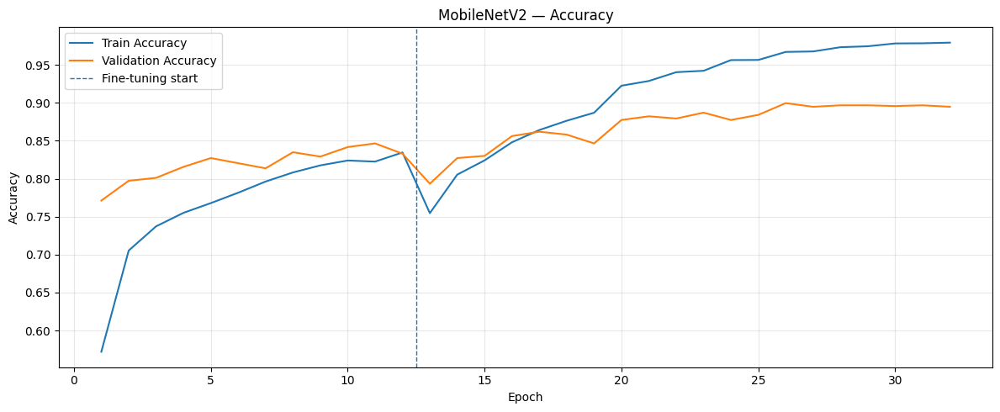

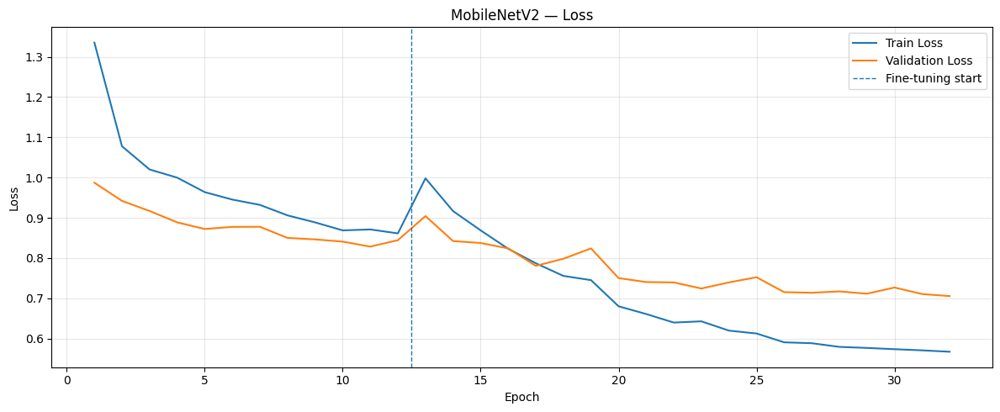

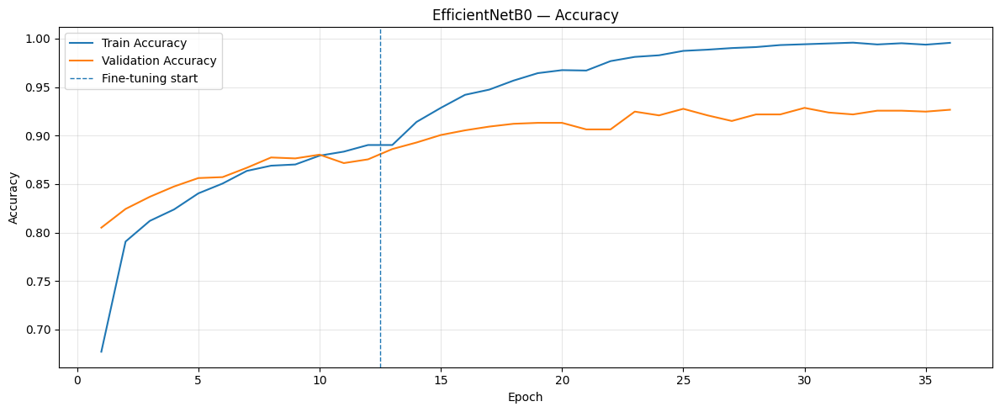

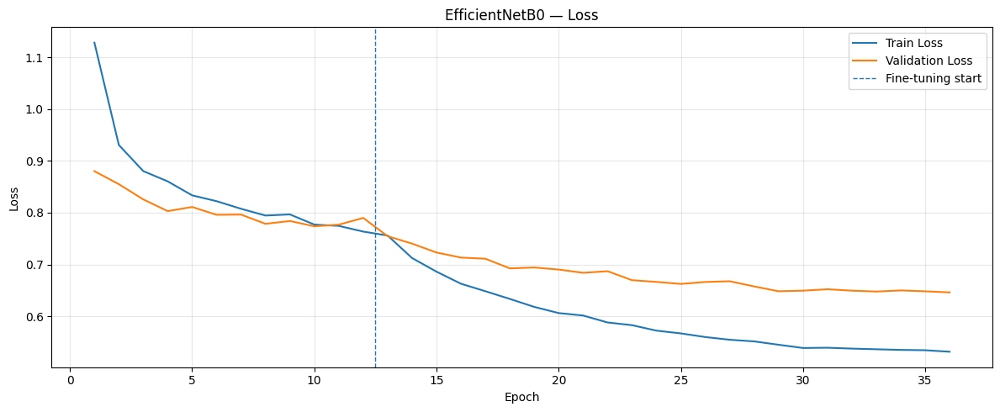

In [ ]:
# 13. Learning Curves

def merge_histories(history_a, history_b):
    merged = {}
    for key in history_a.history.keys():
        merged[key] = list(history_a.history[key]) + list(history_b.history.get(key, []))
    return merged

def plot_learning_curves(history_a, history_b, title):
    history = merge_histories(history_a, history_b)
    epochs = range(1, len(history["loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.plot(epochs, history["accuracy"], label="Train Accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
    plt.axvline(
        len(history_a.history["loss"]) + 0.5,
        linestyle="--",
        linewidth=1,
        label="Fine-tuning start",
    )
    plt.title(f"{title} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(epochs, history["loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.axvline(
        len(history_a.history["loss"]) + 0.5,
        linestyle="--",
        linewidth=1,
        label="Fine-tuning start",
    )
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curves(history_mn_base, history_mn_ft, "MobileNetV2")
plot_learning_curves(history_en_base, history_en_ft, "EfficientNetB0")


# 8. Test Evaluation, F1-Score, Confusion Matrix, and TTA


In [ ]:
# 14. Prediction + Evaluation Helpers

def predict_probabilities(model, dataset, use_tta=False):
    probs = model.predict(dataset, verbose=0)

    if not use_tta:
        return probs

    tta_ds = (
        dataset
        .map(
            lambda images, labels: (tf.image.flip_left_right(images), labels),
            num_parallel_calls=AUTOTUNE,
        )
        .prefetch(AUTOTUNE)
    )
    flipped_probs = model.predict(tta_ds, verbose=0)

    return (probs + flipped_probs) / 2.0

def evaluate_model(model, dataset, model_name, use_tta=False):
    probs = predict_probabilities(model, dataset, use_tta=use_tta)
    y_pred = np.argmax(probs, axis=1)

    y_true = np.concatenate([
        np.argmax(labels.numpy(), axis=1)
        for _, labels in dataset
    ])

    metrics = {
        "Model": model_name,
        "TTA": bool(use_tta),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }

    print(f"\n{'='*20} {model_name} {'='*20}")
    print("TTA:", use_tta)
    print(classification_report(
        y_true,
        y_pred,
        target_names=TARGET_CLASSES,
        digits=4,
        zero_division=0,
    ))

    return y_true, y_pred, probs, metrics

y_true_mn, y_pred_mn, probs_mn, metrics_mn = evaluate_model(
    mobilenet_model, test_ds, "MobileNetV2", use_tta=False
)

y_true_en, y_pred_en, probs_en, metrics_en = evaluate_model(
    efficientnet_model, test_ds, "EfficientNetB0", use_tta=False
)

assert np.array_equal(y_true_mn, y_true_en)
assert np.array_equal(y_true_mn, np.concatenate([
    np.argmax(labels.numpy(), axis=1) for _, labels in test_ds
]))

comparison_df = pd.DataFrame([metrics_mn, metrics_en])
display(comparison_df.style.format({
    "Accuracy": "{:.4f}",
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Weighted F1": "{:.4f}",
}))



==================== MobileNetV2 ====================
TTA: False
              precision    recall  f1-score   support

   cardboard     0.8852    0.8372    0.8606       129
       glass     0.8571    0.9120    0.8837       125
       metal     0.8742    0.8980    0.8859       147
       paper     0.8244    0.8710    0.8471       124
     plastic     0.9007    0.8909    0.8958       275
       trash     0.9207    0.8856    0.9028       236

    accuracy                         0.8842      1036
   macro avg     0.8771    0.8824    0.8793      1036
weighted avg     0.8852    0.8842    0.8843      1036


==================== EfficientNetB0 ====================
TTA: False
              precision    recall  f1-score   support

   cardboard     0.9375    0.9302    0.9339       129
       glass     0.9070    0.9360    0.9213       125
       metal     0.9216    0.9592    0.9400       147
       paper     0.9280    0.9355    0.9317       124
     plastic     0.9236    0.9236    0.9236       2

,Model,TTA,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,MobileNetV2,False,0.8842,0.8771,0.8824,0.8793,0.8843
1,EfficientNetB0,False,0.9344,0.9319,0.9361,0.9338,0.9345


In [ ]:
# ============================================================
# 15. TTA Experiment (Optional, reported separately)
# ============================================================

y_true_mn_tta, y_pred_mn_tta, probs_mn_tta, metrics_mn_tta = evaluate_model(
    mobilenet_model, test_ds, "MobileNetV2", use_tta=True
)

y_true_en_tta, y_pred_en_tta, probs_en_tta, metrics_en_tta = evaluate_model(
    efficientnet_model, test_ds, "EfficientNetB0", use_tta=True
)

tta_comparison = pd.DataFrame([metrics_mn_tta, metrics_en_tta])
display(tta_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Weighted F1": "{:.4f}",
}))

In [ ]:
# 16. Confusion Matrices
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        square=True,
        xticklabels=TARGET_CLASSES,
        yticklabels=TARGET_CLASSES,
    )
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    y_true_mn,
    y_pred_mn,
    "Confusion Matrix — MobileNetV2 (Standard Test)",
)

plot_confusion_matrix(
    y_true_en,
    y_pred_en,
    "Confusion Matrix — EfficientNetB0 (Standard Test)",
)


### Ensemble MobileNetV2 + EfficientNetB0

Probabilitas kedua model dirata-ratakan. Ensemble biasanya menaikkan akurasi karena kedua backbone membuat kesalahan yang berbeda. Hasilnya dilaporkan **terpisah** dari model tunggal, baik tanpa TTA maupun dengan TTA.

              precision    recall  f1-score   support

   cardboard     0.9219    0.9147    0.9183       129
       glass     0.9055    0.9200    0.9127       125
       metal     0.9097    0.9592    0.9338       147
       paper     0.9180    0.9032    0.9106       124
     plastic     0.9262    0.9127    0.9194       275
       trash     0.9399    0.9280    0.9339       236

    accuracy                         0.9228      1036
   macro avg     0.9202    0.9230    0.9214      1036
weighted avg     0.9230    0.9228    0.9227      1036



,Model,TTA,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,MobileNetV2,False,0.8842,0.8771,0.8824,0.8793,0.8843
1,EfficientNetB0,False,0.9344,0.9319,0.9361,0.9338,0.9345
2,MobileNetV2,True,0.8871,0.8811,0.8844,0.8822,0.8873
3,EfficientNetB0,True,0.9353,0.9304,0.9356,0.9328,0.9354
4,Ensemble (MobileNetV2 + EfficientNetB0),False,0.9199,0.9176,0.9207,0.9191,0.9199
5,Ensemble (MobileNetV2 + EfficientNetB0),True,0.9228,0.9202,0.9230,0.9214,0.9227


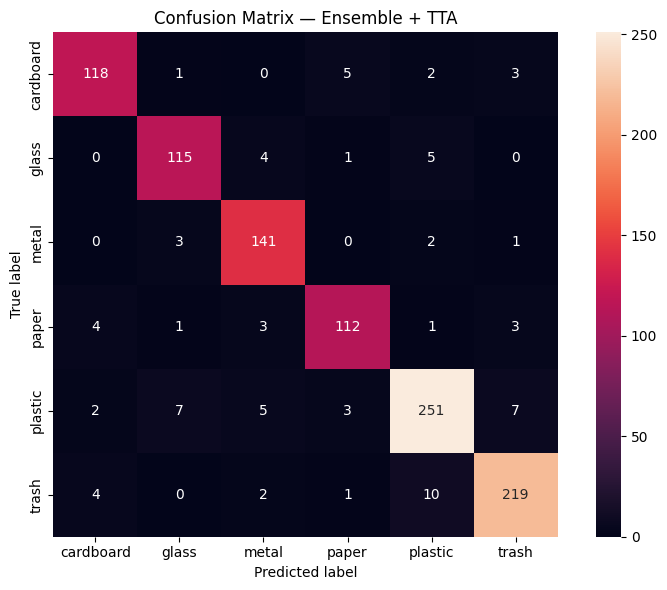

In [ ]:
# 15b. Ensemble (average of probabilities)

def metrics_from_probs(y_true, probs, name, use_tta):
    y_pred = np.argmax(probs, axis=1)
    return y_pred, {
        "Model": name,
        "TTA": bool(use_tta),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

probs_ens = (probs_mn + probs_en) / 2.0
probs_ens_tta = (probs_mn_tta + probs_en_tta) / 2.0

y_pred_ens, metrics_ens = metrics_from_probs(
    y_true_mn, probs_ens, "Ensemble (MobileNetV2 + EfficientNetB0)", use_tta=False
)
y_pred_ens_tta, metrics_ens_tta = metrics_from_probs(
    y_true_mn, probs_ens_tta, "Ensemble (MobileNetV2 + EfficientNetB0)", use_tta=True
)

print(classification_report(
    y_true_mn, y_pred_ens_tta, target_names=TARGET_CLASSES, digits=4, zero_division=0
))

all_results = pd.DataFrame([
    metrics_mn, metrics_en, metrics_mn_tta, metrics_en_tta, metrics_ens, metrics_ens_tta
])
display(all_results.style.format({
    "Accuracy": "{:.4f}", "Macro Precision": "{:.4f}", "Macro Recall": "{:.4f}",
    "Macro F1": "{:.4f}", "Weighted F1": "{:.4f}",
}))

plot_confusion_matrix(
    y_true_mn, y_pred_ens_tta, "Confusion Matrix — Ensemble + TTA"
)

# 9. Error Analysis


Jumlah error EfficientNetB0: 68


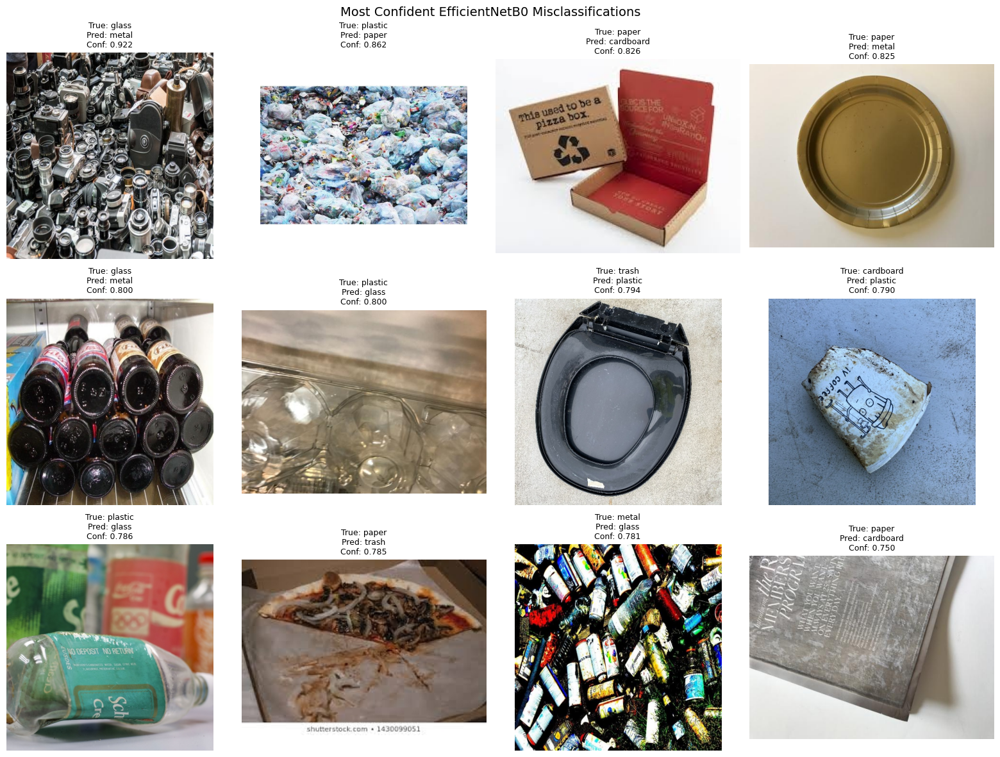

In [ ]:
# 17. Error Analysis — Most Confident Wrong Predictions

test_order = sorted(
    [p for p in (DATASET_DIR / "test").rglob("*") if p.is_file()],
    key=lambda p: str(p).lower(),
)

test_paths = [str(p) for p in test_order]

# Reconstruct true labels from directory structure, matching TF's
# alphabetical file ordering when shuffle=False.
test_true_from_paths = np.array([
    label_to_index[p.parent.name]
    for p in test_order
])

if len(test_true_from_paths) != len(y_true_mn):
    raise RuntimeError("Test manifest length does not match model predictions.")

assert np.array_equal(test_true_from_paths, y_true_mn)

error_indices = np.where(y_pred_en != y_true_mn)[0]
error_confidence = np.max(probs_en[error_indices], axis=1)

ranked_errors = error_indices[np.argsort(-error_confidence)]

print("Jumlah error EfficientNetB0:", len(ranked_errors))

n_show = min(12, len(ranked_errors))
if n_show == 0:
    print("Tidak ada kesalahan klasifikasi pada test set.")
else:
    plt.figure(figsize=(16, 12))

    for i, idx in enumerate(ranked_errors[:n_show]):
        img = Image.open(test_paths[idx]).convert("RGB")

        ax = plt.subplot(3, 4, i + 1)
        ax.imshow(img)
        ax.set_title(
            f"True: {TARGET_CLASSES[y_true_mn[idx]]}\n"
            f"Pred: {TARGET_CLASSES[y_pred_en[idx]]}\n"
            f"Conf: {probs_en[idx].max():.3f}",
            fontsize=9,
        )
        ax.axis("off")

    plt.suptitle("Most Confident EfficientNetB0 Misclassifications", fontsize=14)
    plt.tight_layout()
    plt.show()


Pasangan kesalahan terbanyak (true -> pred):
      trash -> plastic  : 10
    plastic -> trash    : 7
    plastic -> glass    : 7
  cardboard -> paper    : 5
      glass -> plastic  : 5
    plastic -> metal    : 5
      glass -> metal    : 4
      paper -> cardboard: 4


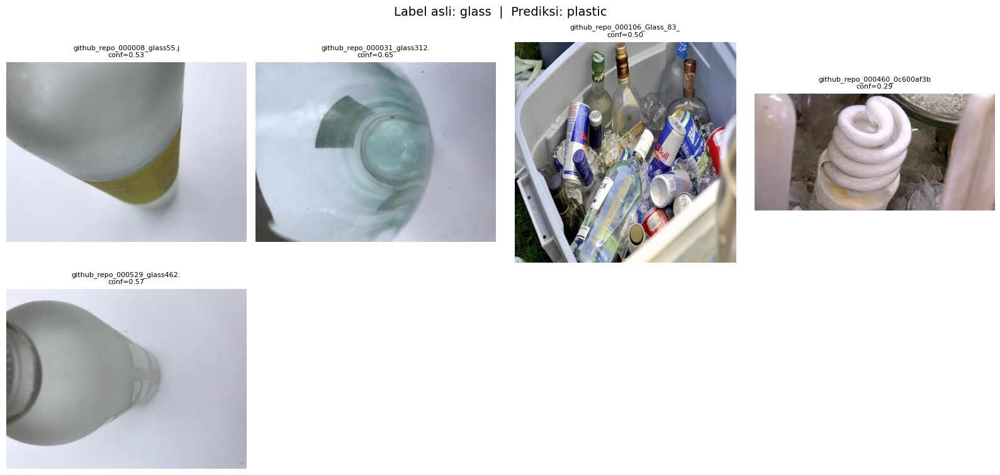

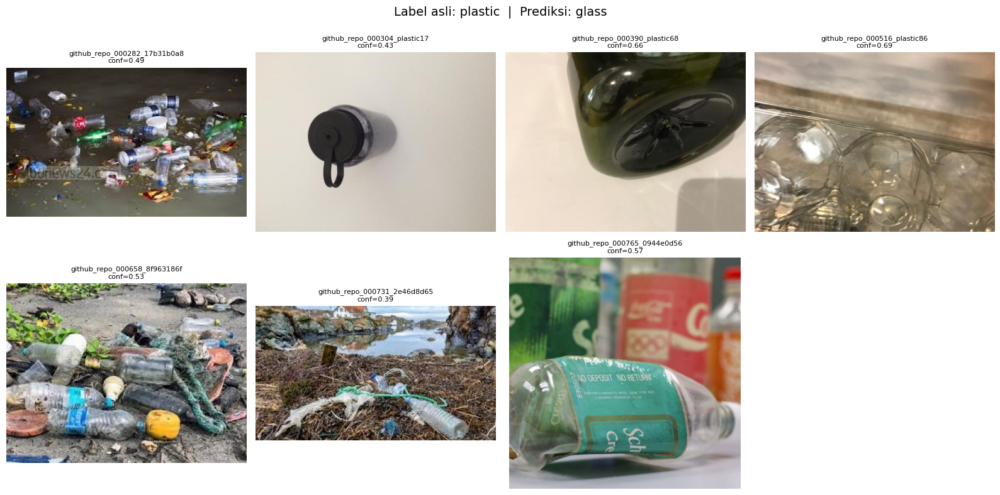

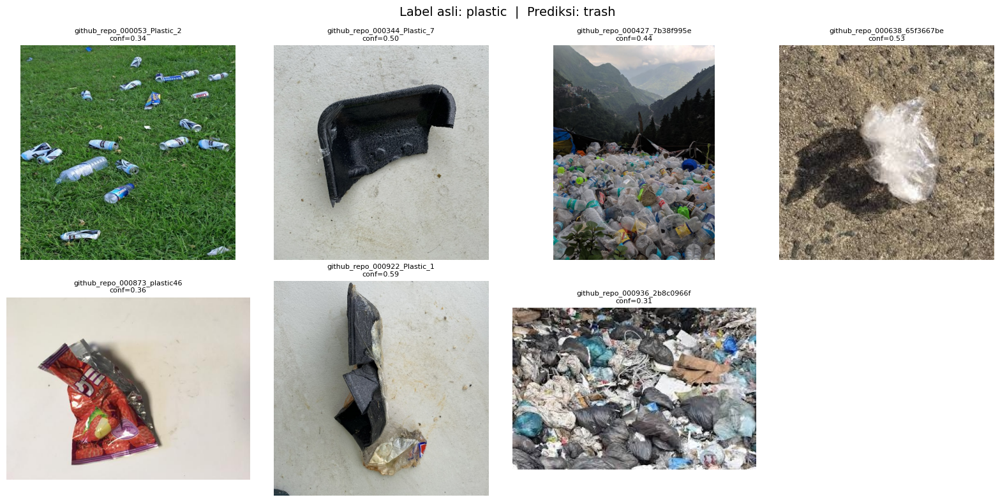

In [ ]:
from collections import Counter
import math

pairs = Counter(
    (TARGET_CLASSES[t], TARGET_CLASSES[p])
    for t, p in zip(y_true_mn, y_pred_ens_tta) if t != p
)
print("Pasangan kesalahan terbanyak (true -> pred):")
for (t, p), n in pairs.most_common(8):
    print(f"  {t:>9} -> {p:<9}: {n}")

def show_confusions(true_cls, pred_cls, max_n=12):
    t, p = label_to_index[true_cls], label_to_index[pred_cls]
    idxs = np.where((y_true_mn == t) & (y_pred_ens_tta == p))[0][:max_n]
    if len(idxs) == 0:
        print("Tidak ada kasus.")
        return
    cols = 4
    rows = math.ceil(len(idxs) / cols)
    plt.figure(figsize=(16, 4 * rows))
    for k, idx in enumerate(idxs):
        ax = plt.subplot(rows, cols, k + 1)
        ax.imshow(Image.open(test_paths[idx]).convert("RGB"))
        ax.set_title(f"{Path(test_paths[idx]).name[:28]}\nconf={probs_ens_tta[idx].max():.2f}", fontsize=8)
        ax.axis("off")
    plt.suptitle(f"Label asli: {true_cls}  |  Prediksi: {pred_cls}", fontsize=14)
    plt.tight_layout()
    plt.show()

show_confusions("glass", "plastic")
show_confusions("plastic", "glass")
show_confusions("plastic", "trash")

# 10. Grad-CAM Explainable AI

Grad-CAM dipertahankan sebagai bagian XAI, tetapi implementasinya diperbaiki agar tidak bergantung pada indeks `model.layers[3]`, `model.layers[4]`, dan seterusnya.

Implementasi menggunakan nama layer eksplisit (`global_average_pool`, `head_dropout_in`, `head_dense`, `head_dropout`, `classifier`) dan mencari layer konvolusional 4D terakhir secara otomatis pada backbone.

In [ ]:
# 18. Robust Grad-CAM

def find_last_conv_layer(base_model):
    candidates = []

    for layer in base_model.layers:
        try:
            output_shape = tuple(layer.output.shape)
            if len(output_shape) == 4:
                candidates.append(layer)
        except Exception:
            continue

    if not candidates:
        raise ValueError("Tidak ditemukan layer feature map 4D pada backbone.")

    return candidates[-1]

def make_gradcam_heatmap(image_batch, model, base_model, class_index=None):
    preprocess_layer = model.get_layer("input_preprocess")
    target_layer = find_last_conv_layer(base_model)

    # Since the selected layer is the final 4D feature-map layer,
    # use it as the Grad-CAM target and continue through the classifier head.
    feature_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=target_layer.output,
    )

    preprocessed = preprocess_layer(image_batch)

    with tf.GradientTape() as tape:
        conv_outputs = feature_model(preprocessed, training=False)
        x = model.get_layer("global_average_pool")(conv_outputs)
        x = model.get_layer("head_dropout_in")(x, training=False)
        x = model.get_layer("head_dense")(x)
        x = model.get_layer("head_dropout")(x, training=False)
        predictions = model.get_layer("classifier")(x)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_channel = predictions[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap[0]
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy(), int(class_index.numpy()), target_layer.name

def overlay_gradcam(image_rgb, heatmap, alpha=0.40):
    heatmap_resized = cv2.resize(
        heatmap,
        (image_rgb.shape[1], image_rgb.shape[0]),
    )
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = (
        (1 - alpha) * image_rgb.astype(np.float32)
        + alpha * heatmap_color.astype(np.float32)
    )

    return np.clip(overlay, 0, 255).astype(np.uint8)

# Use a test image with a valid prediction.
sample_path = test_paths[0]
sample_img = Image.open(sample_path).convert("RGB")
sample_img_resized = sample_img.resize(IMG_SIZE)
sample_array = np.asarray(sample_img_resized, dtype=np.float32)
sample_batch = np.expand_dims(sample_array, axis=0)

heatmap_mn, pred_idx_mn, conv_name_mn = make_gradcam_heatmap(
    sample_batch,
    mobilenet_model,
    mobilenet_base,
)

overlay_mn = overlay_gradcam(sample_array.astype(np.uint8), heatmap_mn)

true_idx = label_to_index[Path(sample_path).parent.name]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_array.astype(np.uint8))
plt.title(
    f"Original\nTrue: {TARGET_CLASSES[true_idx]}\n"
    f"Pred: {TARGET_CLASSES[pred_idx_mn]}"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_mn, cmap="jet")
plt.title(f"Grad-CAM\nLayer: {conv_name_mn}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_mn)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

# 11. Final Model Comparison & Saving

Model final dibandingkan menggunakan **standard test metrics**, bukan hanya accuracy.

Model dengan accuracy lebih tinggi belum otomatis lebih baik apabila macro F1 jauh lebih rendah. Untuk dataset yang tidak seimbang, macro F1 digunakan sebagai indikator keseimbangan performa antarkelas.


In [ ]:
# 19. Final Comparison + Model Size

mobilenet_path = "/content/final_mobilenet_v2.keras"
efficientnet_path = "/content/final_efficientnet_b0.keras"

mobilenet_model.save(mobilenet_path)
efficientnet_model.save(efficientnet_path)

def file_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2)

final_comparison = pd.DataFrame([
    {
        **metrics_mn,
        "Model Size (MB)": file_size_mb(mobilenet_path),
    },
    {
        **metrics_en,
        "Model Size (MB)": file_size_mb(efficientnet_path),
    },
])

display(final_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Weighted F1": "{:.4f}",
    "Model Size (MB)": "{:.2f}",
}))

best_model_row = final_comparison.sort_values(
    by=["Macro F1", "Accuracy"],
    ascending=False,
).iloc[0]

print(
    f"Model terbaik berdasarkan Macro F1 lalu Accuracy: "
    f"{best_model_row['Model']}"
)
print(f"Saved MobileNetV2 : {mobilenet_path}")
print(f"Saved EfficientNetB0: {efficientnet_path}")
print(f"Saved dataset manifest: {manifest_path}")


,Model,TTA,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Model Size (MB)
0,MobileNetV2,False,0.8842,0.8771,0.8824,0.8793,0.8843,27.71
1,EfficientNetB0,False,0.9344,0.9319,0.9361,0.9338,0.9345,45.51


Model terbaik berdasarkan Macro F1 lalu Accuracy: EfficientNetB0
Saved MobileNetV2 : /content/final_mobilenet_v2.keras
Saved EfficientNetB0: /content/final_efficientnet_b0.keras
Saved dataset manifest: /content/waste_dataset_manifest.csv


Menjalankan Grad-CAM pada 6 gambar ...
[0009_Cardboard_270.jpg] MobileNetV2     layer=out_relu        raw_max=2.09e-01
[0009_Cardboard_270.jpg] EfficientNetB0  layer=top_activation  raw_max=9.95e-02
[po_000004_glass448.jpg] MobileNetV2     layer=out_relu        raw_max=2.55e-01
[po_000004_glass448.jpg] EfficientNetB0  layer=top_activation  raw_max=1.88e-01
[_000001_Metal_146_.jpg] MobileNetV2     layer=out_relu        raw_max=2.87e-01
[_000001_Metal_146_.jpg] EfficientNetB0  layer=top_activation  raw_max=1.63e-01
[po_000000_paper170.jpg] MobileNetV2     layer=out_relu        raw_max=3.52e-01
[po_000000_paper170.jpg] EfficientNetB0  layer=top_activation  raw_max=1.04e-01
[000002_Plastic_626.jpg] MobileNetV2     layer=out_relu        raw_max=2.23e-01
[000002_Plastic_626.jpg] EfficientNetB0  layer=top_activation  raw_max=2.02e-01
[_000015_04a5fe7fae.jpg] MobileNetV2     layer=out_relu        raw_max=1.59e-01
[_000015_04a5fe7fae.jpg] EfficientNetB0  layer=top_activation  raw_max=9.19e-02


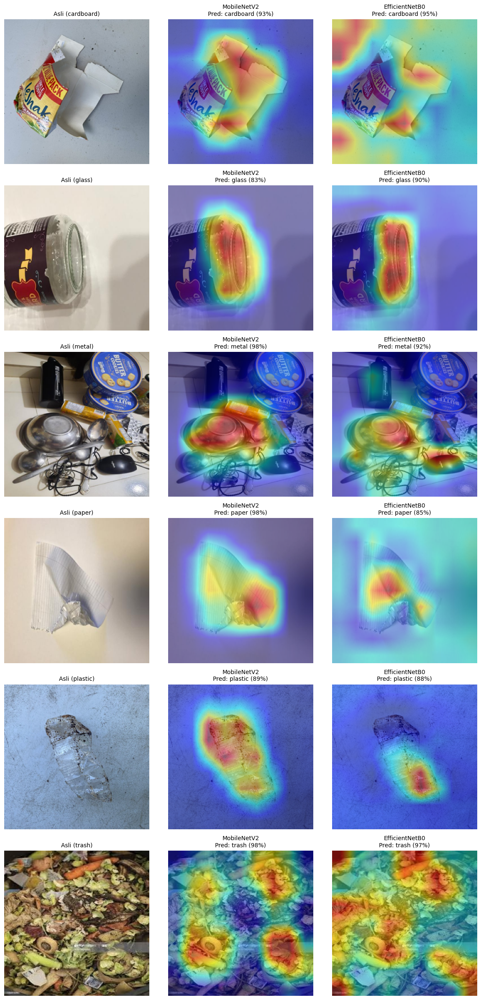

Selesai.


In [ ]:
# Grad-CAM v2: MobileNetV2 vs EfficientNetB0
import cv2, math
from PIL import Image

def find_last_conv_layer(base_model):
    candidates = []
    for layer in base_model.layers:
        try:
            if len(tuple(layer.output.shape)) == 4:
                candidates.append(layer)
        except Exception:
            continue
    if not candidates:
        raise ValueError("Tidak ditemukan layer feature map 4D pada backbone.")
    return candidates[-1]

def make_gradcam_heatmap(image_batch, model, base_model, class_index=None):
    preprocess_layer = model.get_layer("input_preprocess")
    classifier = model.get_layer("classifier")
    target_layer = find_last_conv_layer(base_model)
    feature_model = tf.keras.Model(base_model.input, target_layer.output)

    x_in = preprocess_layer(tf.convert_to_tensor(image_batch, dtype=tf.float32))
    conv_outputs = feature_model(x_in, training=False)

    with tf.GradientTape() as tape:
        tape.watch(conv_outputs)                       # tidak bergantung pada layer trainable/frozen
        x = model.get_layer("global_average_pool")(conv_outputs)
        x = model.get_layer("head_dropout_in")(x, training=False)
        x = model.get_layer("head_dense")(x)
        x = model.get_layer("head_dropout")(x, training=False)
        logits = tf.matmul(x, classifier.kernel) + classifier.bias   # PRE-softmax (tidak saturasi)
        if class_index is None:
            class_index = int(tf.argmax(logits[0]))
        class_score = logits[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)
    if grads is None:
        raise RuntimeError("Gradien None: graf antara feature map dan output terputus.")

    pooled = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    heatmap = tf.maximum(tf.reduce_sum(conv_outputs * pooled, axis=-1)[0], 0).numpy()

    raw_max = float(heatmap.max())
    if raw_max > 0:
        heatmap = heatmap / raw_max                    # normalisasi relatif, tanpa epsilon tetap
    return heatmap, class_index, target_layer.name, raw_max

def overlay_gradcam(image_rgb, heatmap, alpha=0.45):
    hm = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
    hm = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    out = (1 - alpha) * image_rgb.astype(np.float32) + alpha * hm.astype(np.float32)
    return np.clip(out, 0, 255).astype(np.uint8)

def load_for_model(path):
    img = Image.open(path).convert("RGB").resize(IMG_SIZE)
    arr = np.asarray(img, dtype=np.float32)
    return arr.astype(np.uint8), arr[None]

def show_gradcam_grid(paths):
    models = [("MobileNetV2", mobilenet_model, mobilenet_base),
              ("EfficientNetB0", efficientnet_model, efficientnet_base)]
    fig, axes = plt.subplots(len(paths), 3, figsize=(12, 4 * len(paths)), squeeze=False)

    for r, path in enumerate(paths):
        img_u8, batch = load_for_model(path)
        true_name = Path(path).parent.name
        axes[r][0].imshow(img_u8)
        axes[r][0].set_title(f"Asli ({true_name})", fontsize=10)
        axes[r][0].axis("off")

        for c, (name, model, base) in enumerate(models, start=1):
            try:
                probs = model.predict(batch, verbose=0)[0]
                heat, idx, layer, raw_max = make_gradcam_heatmap(batch, model, base)
                axes[r][c].imshow(overlay_gradcam(img_u8, heat))
                axes[r][c].set_title(f"{name}\nPred: {TARGET_CLASSES[idx]} ({probs[idx]:.0%})", fontsize=10)
                print(f"[{Path(path).name[-22:]}] {name:<15} layer={layer:<15} raw_max={raw_max:.2e}")
            except Exception as e:
                axes[r][c].text(0.5, 0.5, f"ERROR\n{type(e).__name__}", ha="center", va="center")
                print(f"[{Path(path).name[-22:]}] {name} ERROR: {type(e).__name__}: {e}")
            axes[r][c].axis("off")

    plt.tight_layout()
    plt.show()

# Satu contoh test per kelas (tambahkan path sendiri ke daftar ini bila perlu)
sample_paths = []
for cls in TARGET_CLASSES:
    for p in test_paths:
        if Path(p).parent.name == cls:
            sample_paths.append(p)
            break

print("Menjalankan Grad-CAM pada", len(sample_paths), "gambar ...")
show_gradcam_grid(sample_paths)
print("Selesai.")

Saving image_2026-10-07_204430544.png to image_2026-10-07_204430544.png
File: image_2026-10-07_204430544.png


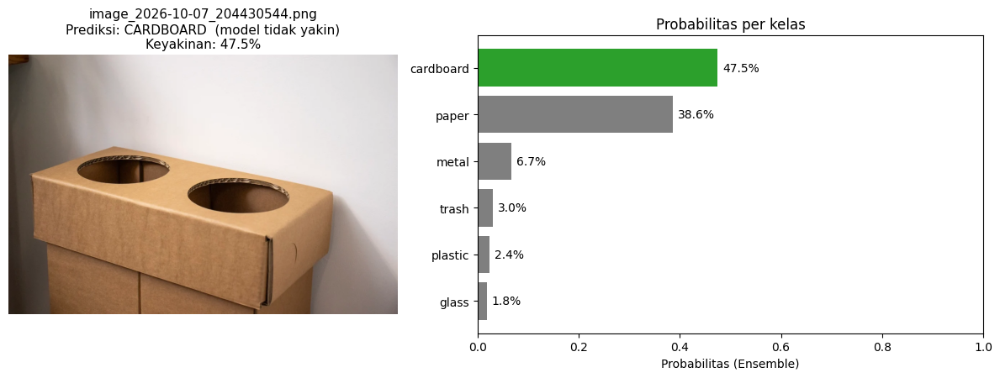

Detail per model:
  MobileNetV2    : paper      (73.0%)
  EfficientNetB0 : cardboard  (84.9%)
  Ensemble       : cardboard  (47.5%)

Catatan: keyakinan rendah. Model hanya mengenal 6 kelas (cardboard, glass, metal, paper, plastic, trash). Coba foto yang lebih jelas dengan objek tunggal di tengah.


In [ ]:
# Prediksi Gambar Baru (Upload -> Tebak Kelas Sampah)
import io
from PIL import Image, ImageOps

# Muat model dari memori; jika runtime di-restart, muat dari file hasil penyimpanan.
def _get_model(var_name, saved_path):
    if var_name in globals():
        return globals()[var_name]
    if os.path.exists(saved_path):
        print(f"Memuat {saved_path} ...")
        return tf.keras.models.load_model(saved_path)
    raise FileNotFoundError(
        f"Model '{var_name}' tidak ada di memori dan {saved_path} tidak ditemukan. "
        "Jalankan cell training dan cell penyimpanan model terlebih dahulu."
    )

infer_mobilenet = _get_model("mobilenet_model", "/content/final_mobilenet_v2.keras")
infer_efficientnet = _get_model("efficientnet_model", "/content/final_efficientnet_b0.keras")

CONFIDENCE_THRESHOLD = 0.50  # di bawah ini, hasil ditandai "tidak yakin"

def prepare_image(pil_image):
    """Preprocessing identik dengan training: RGB, resize 224x224 (bilinear), skala 0-255."""
    pil_image = ImageOps.exif_transpose(pil_image).convert("RGB")
    arr = tf.keras.utils.img_to_array(pil_image)       # float32, 0-255
    arr = tf.image.resize(arr, IMG_SIZE).numpy()
    return pil_image, np.expand_dims(arr, axis=0)

def predict_probs(batch, use_tta=True):
    """Probabilitas MobileNetV2, EfficientNetB0, dan rata-rata keduanya (Ensemble)."""
    inputs = [batch]
    if use_tta:
        inputs.append(batch[:, :, ::-1, :])             # flip horizontal
    result = {}
    for name, model in [("MobileNetV2", infer_mobilenet),
                        ("EfficientNetB0", infer_efficientnet)]:
        result[name] = np.mean([model.predict(x, verbose=0)[0] for x in inputs], axis=0)
    result["Ensemble"] = (result["MobileNetV2"] + result["EfficientNetB0"]) / 2.0
    return result

def show_prediction(pil_image, probs_by_model, title=""):
    ensemble = probs_by_model["Ensemble"]
    order = np.argsort(-ensemble)
    top_idx = int(order[0])
    top_conf = float(ensemble[top_idx])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5),
                             gridspec_kw={"width_ratios": [1, 1.3]})

    axes[0].imshow(pil_image)
    axes[0].axis("off")
    verdict = TARGET_CLASSES[top_idx].upper()
    if top_conf < CONFIDENCE_THRESHOLD:
        verdict += "  (model tidak yakin)"
    axes[0].set_title(f"{title}\nPrediksi: {verdict}\nKeyakinan: {top_conf:.1%}", fontsize=11)

    names = [TARGET_CLASSES[i] for i in order][::-1]
    values = [ensemble[i] for i in order][::-1]
    colors = ["tab:green" if n == TARGET_CLASSES[top_idx] else "tab:gray" for n in names]
    axes[1].barh(names, values, color=colors)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probabilitas (Ensemble)")
    axes[1].set_title("Probabilitas per kelas")
    for y, v in enumerate(values):
        axes[1].text(min(v + 0.01, 0.88), y, f"{v:.1%}", va="center")
    plt.tight_layout()
    plt.show()

    print("Detail per model:")
    for name in ["MobileNetV2", "EfficientNetB0", "Ensemble"]:
        p = probs_by_model[name]
        k = int(np.argmax(p))
        print(f"  {name:<15}: {TARGET_CLASSES[k]:<10} ({p[k]:.1%})")
    if top_conf < CONFIDENCE_THRESHOLD:
        print("\nCatatan: keyakinan rendah. Model hanya mengenal 6 kelas "
              f"({', '.join(TARGET_CLASSES)}). Coba foto yang lebih jelas "
              "dengan objek tunggal di tengah.")

def predict_from_pil(pil_image, title="", use_tta=True):
    pil_rgb, batch = prepare_image(pil_image)
    probs = predict_probs(batch, use_tta=use_tta)
    show_prediction(pil_rgb, probs, title=title)
    return probs

def upload_and_predict(use_tta=True):
    """Colab: tombol upload. Di luar Colab: minta path file."""
    try:
        from google.colab import files
        uploaded = files.upload()                       # pilih 1 atau beberapa gambar
        items = [(name, Image.open(io.BytesIO(data))) for name, data in uploaded.items()]
    except ImportError:
        paths = input("Masukkan path gambar (pisahkan dengan koma): ").split(",")
        items = [(Path(p.strip()).name, Image.open(p.strip())) for p in paths if p.strip()]

    for name, img in items:
        print("=" * 70)
        print("File:", name)
        predict_from_pil(img, title=name, use_tta=use_tta)

upload_and_predict(use_tta=True)